# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Brence, cac7bf

**Date:** 09/09/2026

In [41]:
# QUESTION 2
# PART 1

# import necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# read csv to dataframe
df = pd.read_csv("ForeignGifts_edu.csv")

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

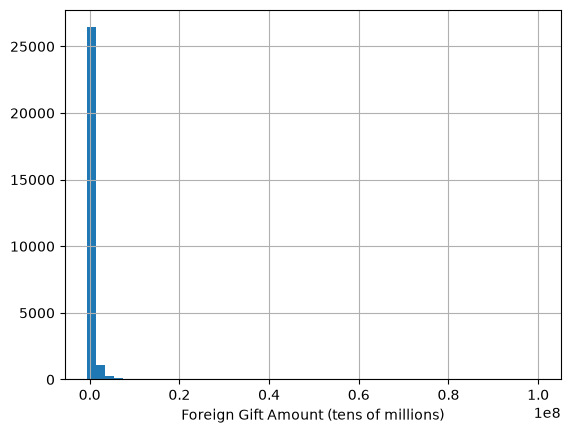

In [42]:
# QUESTION 2
# PART 2

# create histogram
df["Foreign Gift Amount"].hist(bins=50).set_xlabel("Foreign Gift Amount (tens of millions)")

# describe variable 
df["Foreign Gift Amount"].describe()

The describe function and histogram reveal that most entries in "Foreign Gift Amount" fall within the span of a few hundred dollars to tens of thousands, with a 25th percentile value of 570, 75th percentile value of 37614, and an interquartile range of 37614 - 570 = 37044. However, there are also several outliers present in the data, namely the maximum value of 10 million (explaining the skewed histogram) and minimum value (-53777) in the negative range, the latter of which not making sense in the context of gifts. 

In [43]:
# QUESTION 2
# PART 3

# create value counts table with 'normalize="index"' to list proportion of each gift type out of all entries, times 100 for percentages
df["Gift Type"].value_counts(normalize=True)*100

Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64

The value counts table reveals that 61.21% of all gifts are Contracts, with 38.75% being Monetary Gifts and a measly 0.04% are Real Estate.

c:\Users\nafer\anaconda3\envs\DS3001\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


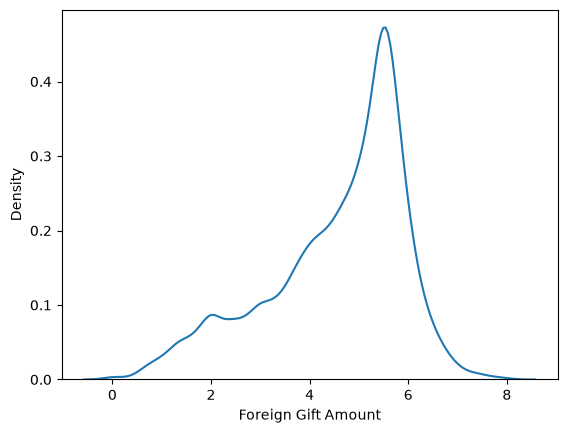

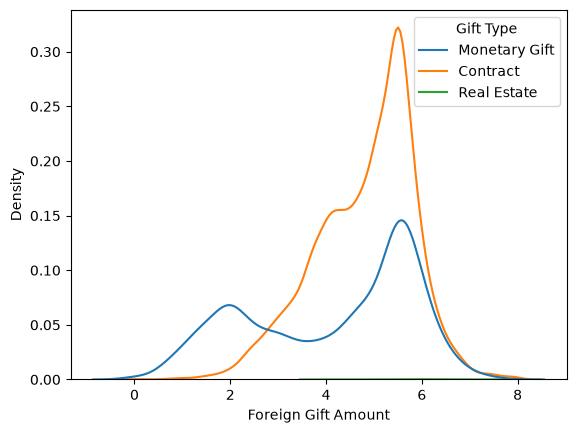

In [44]:
# QUESTION 2
# PART 4

# create mcopy of df and manipulate Foreign Gift Amount column to get log of each entry
df_log = df.copy()
df_log["Foreign Gift Amount"] = np.log10(df_log["Foreign Gift Amount"])

# create first kdeplot
sns.kdeplot(data=df_log, x="Foreign Gift Amount", bw_method="silverman")
plt.show()

# create second kdeplot, with one curve for each gift type
sns.kdeplot(data=df_log, x="Foreign Gift Amount", bw_method="silverman", hue="Gift Type")
plt.show()


When observing the KDE plot that's conditional on gift type, it's evident that all three gift types are most frquently given in values around 5.5 (or ~316000 given the above charts are logarithmic). However, what's notable about the comparison between each KDE plot is that most gifts with amounts below 1000 (or 3 on the log scale) are of the Monetary Gift type, leaving the Contract type to dominate the higher end. 

In [45]:
# QUESTION 2
# PART 5

# Top 15 in terms of gift amount
# Use groupby to sort sum of gift amounts by country, then print the first fifteen with head
df_group = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)
df_group.head(15)


Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [46]:
# Top 15 in terms of number of gifts
# Use groupby to sort count of gift amounts by country, then print the first fifteen with head
df_group2 = df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False)
df_group2.head(15)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

In [47]:
# QUESTION 2
# PART 6

# Use groupby to sort count of gift amounts by giftor name, then print the first fifteen with head
df_name = df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)
df_name.head(15)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [48]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]